In [ ]:
!pip install matplotlib networkx

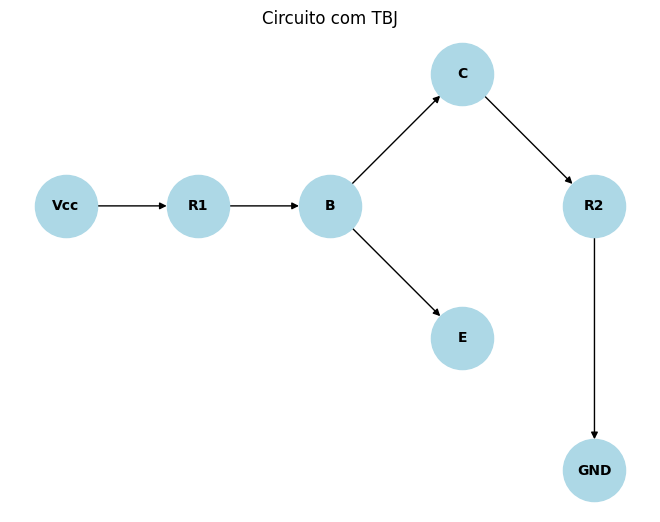

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

# Criar um gráfico direcionado
G = nx.DiGraph()

# Adicionar nós para os componentes do circuito
G.add_node("Vcc", pos=(0, 2))
G.add_node("R1", pos=(1, 2))
G.add_node("B", pos=(2, 2))  # Base do TBJ
G.add_node("C", pos=(3, 3))  # Coletor do TBJ
G.add_node("E", pos=(3, 1))  # Emissor do TBJ
G.add_node("R2", pos=(4, 2))
G.add_node("GND", pos=(4, 0))

# Adicionar arestas para as conexões
G.add_edges_from([("Vcc", "R1"), ("R1", "B"), ("B", "C"), ("B", "E"), ("C", "R2"), ("R2", "GND")])

# Obter as posições dos nós
pos = nx.get_node_attributes(G, 'pos')

# Desenhar o gráfico
nx.draw(G, pos, with_labels=True, node_size=2000, node_color='lightblue', font_size=10, font_weight='bold')
plt.title("Circuito com TBJ")
plt.show()


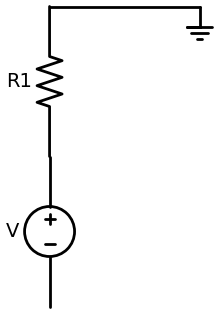

In [ ]:
import schemdraw
import schemdraw.elements as elm

with schemdraw.Drawing() as d:
    d += elm.SourceV().label('V')      # Fonte de tensão
    d += elm.Resistor().label('R1')    # Resistor
    d += elm.Line().right()            # Fio
    d += elm.Ground()                  # Terra
    d.draw()


In [ ]:
from graphviz import Digraph

# Criando o gráfico direcionado (autômato)
automato = Digraph('Automato', filename='automato', format='png')

# Definindo os estados
automato.attr(rankdir='LR')  # Direção da esquerda para a direita
automato.attr('node', shape='circle')

# Adicionando estados
automato.node('q0', label='q0')  # Estado inicial
automato.node('q1', label='q1')
automato.node('q2', label='q2')  # Estado final
automato.node('q3', label='q3')

# Estado final
automato.attr('node', shape='doublecircle')
automato.node('q2')  # Marcando q2 como final

# Transições
automato.edge('q0', 'q1', label='a')
automato.edge('q1', 'q2', label='b')
automato.edge('q2', 'q2', label='b')
automato.edge('q1', 'q3', label='c')
automato.edge('q3', 'q0', label='d')

# Renderizando o gráfico
automato.view()


'automato.png'

In [ ]:
!pip install schemdraw

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.9/131.9 kB 2.2 MB/s eta 0:00:00


In [ ]:
# Schem Draw é Top!!!

#  # Schem Draw, boa ferramenta

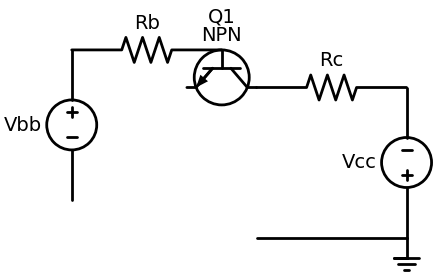

TypeError: 'Drawing' object is not subscriptable

In [ ]:
import schemdraw
import schemdraw.elements as elm

with schemdraw.Drawing() as d:
    # Fonte de tensão da base
    d += elm.SourceV().up().label("Vbb")   # Fonte de tensão da base (polarização)
    d += elm.Resistor().right().label("Rb")  # Resistor de base
    d += elm.BjtNpn(circle=True).down().label("Q1\nNPN")  # Transistor NPN com base polarizada
    d += elm.Resistor().right().label("Rc")  # Resistor de carga no coletor
    d += elm.SourceV().down().label("Vcc")   # Fonte de tensão no coletor
    d += elm.Ground()                         # Terra

    # Conexão da fonte para o emissor
    d += elm.Line().left().at(d['Q1'].emitter)  # Emissor conectado ao terra
    d += elm.Ground()

    d.draw()


In [ ]:
import schemdraw
import schemdraw.elements as elm

with schemdraw.Drawing() as d:
    # Fonte de polarização da base
    d += elm.SourceV().up().label("Vbb")                # Fonte de tensão da base (polarização)
    d += elm.Resistor().right().label("Rb")             # Resistor de base
    bjt = d += elm.BjtNpn(circle=True).down().label("Q1\nNPN")  # Transistor NPN
    d += elm.Line().down().at(bjt.emitter)              # Emissor conectado ao terra
    d += elm.Ground()                                   # Terra do emissor

    # Fonte e resistor de carga no coletor
    d += elm.Line().at(bjt.collector).up()              # Linha conectando ao coletor
    d += elm.Resistor().right().label("Rc")             # Resistor de carga no coletor
    d += elm.SourceV().up().label("Vcc")                # Fonte de tensão no coletor

    d.draw()


SyntaxError: invalid syntax (<ipython-input-8-7201abf05a27>, line 8)

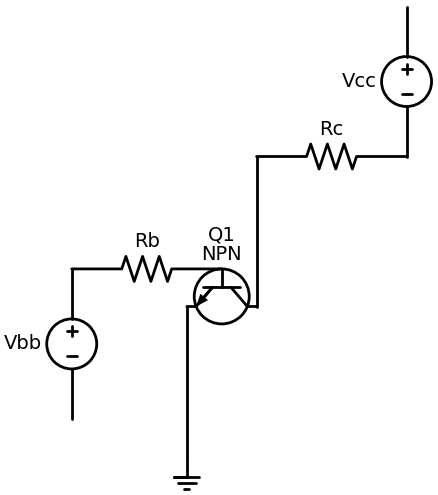

In [ ]:
import schemdraw
import schemdraw.elements as elm

with schemdraw.Drawing() as d:
    # Fonte de polarização da base
    d += elm.SourceV().up().label("Vbb")                # Fonte de tensão da base (polarização)
    d += elm.Resistor().right().label("Rb")             # Resistor de base
    bjt = elm.BjtNpn(circle=True).down().label("Q1\nNPN")  # Transistor NPN
    d += bjt                                            # Adicionando o transistor ao desenho

    # Conexão do emissor ao terra
    d += elm.Line().down().at(bjt.emitter)              # Linha conectando ao emissor
    d += elm.Ground()                                   # Terra do emissor

    # Fonte e resistor de carga no coletor
    d += elm.Line().at(bjt.collector).up()              # Linha conectando ao coletor
    d += elm.Resistor().right().label("Rc")             # Resistor de carga no coletor
    d += elm.SourceV().up().label("Vcc")                # Fonte de tensão no coletor

    d.draw()


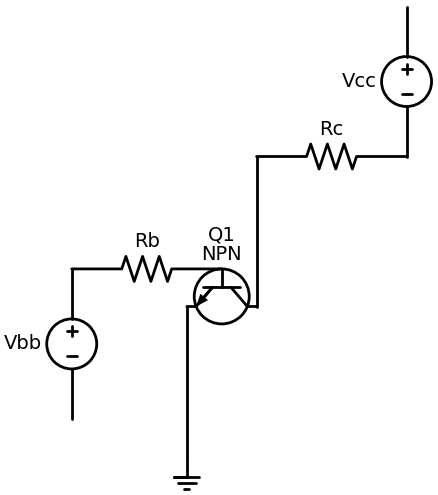

In [ ]:
import schemdraw
import schemdraw.elements as elm

with schemdraw.Drawing() as d:
    # Fonte e resistor de base
    d += elm.SourceV().up().label("Vbb")                # Fonte de tensão da base (polarização)
    d += elm.Resistor().right().label("Rb")             # Resistor de base

    # Transistor NPN
    transistor = elm.BjtNpn(circle=True).down().label("Q1\nNPN")  # Transistor NPN
    d += transistor                                      # Adicionando o transistor

    # Emissor conectado ao terra
    d += elm.Line().down().at(transistor.emitter)        # Linha para o emissor
    d += elm.Ground()                                    # Terra

    # Conexão do coletor ao resistor de carga e fonte
    d += elm.Line().up().at(transistor.collector)        # Linha para o coletor
    d += elm.Resistor().right().label("Rc")              # Resistor de carga no coletor
    d += elm.SourceV().up().label("Vcc")                 # Fonte de tensão no coletor

    d.draw()


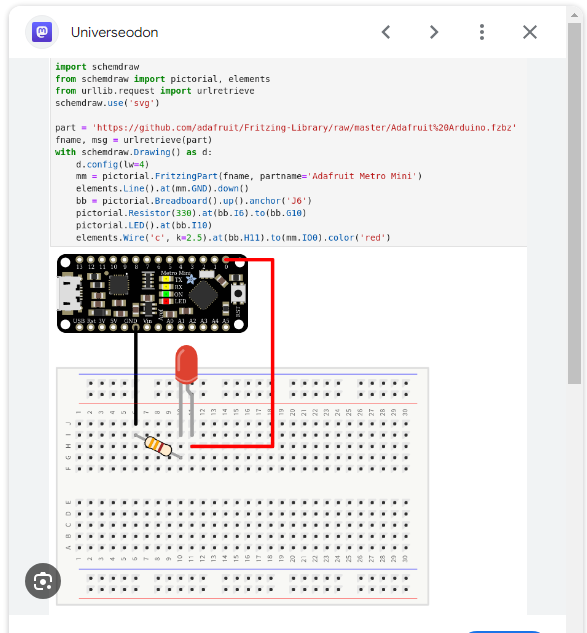

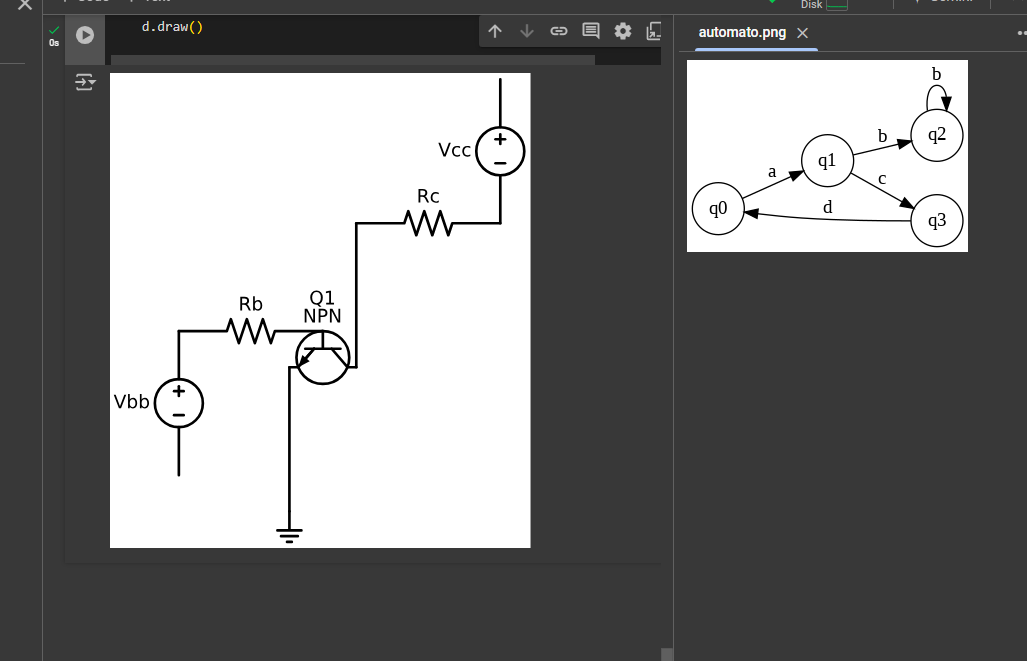

In [ ]:
# Trabalhe com isso, vini. se empenhe na ciência

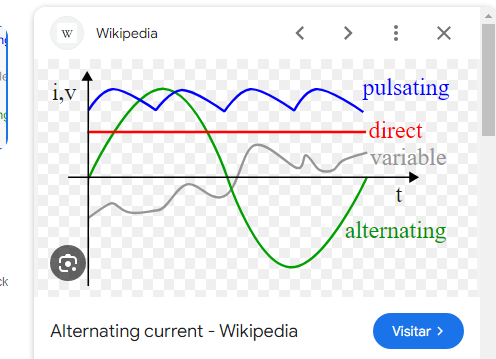